In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [20]:
# Read Excel file
all_sheets = pd.read_excel('analysis/Analysis_v2.xlsx', sheet_name=None)


In [21]:
df_sgt = all_sheets['SGT Descriptors']
df_sgt.columns = df_sgt.iloc[0]
df_sgt = df_sgt[1:]
df_sgt = df_sgt.dropna(axis=1)
#df_sgt

In [22]:
# Filter the relevant materials and parameters
materials = ['BSE 017', 'BSE 011', 'BSE 024', 'BSE 025']
material_names = ['PAN/CGO', 'Carb. PAN', 'PAN', 'Carb. PAN/CGO']
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']

# Filter and pivot
# filtered_df = df_sgt[df_sgt['Material'].isin(materials) & df_sgt['Parameter'].isin(parameters)]
pivot_avg = df_sgt.pivot(index='Material', columns='Parameter', values='Avg.')
pivot_std = df_sgt.pivot(index='Material', columns='Parameter', values='Std. Dev.')

# Ensure consistent parameter order
pivot_avg = pivot_avg[parameters]
pivot_std = pivot_std[parameters]

#print(filtered_df)
print(f"Avg Table:\n{pivot_avg}")

Avg Table:
Parameter   Nodes    Edges        ND Diameter       GD        BC        CC  \
Material                                                                     
BSE 011    7452.5  13942.5  3.741702    98.75   0.0005   0.00493  0.027202   
BSE 017      7777  13819.5  3.553937    113.5  0.00046  0.005188  0.024805   
BSE 024    7763.5  13755.5   3.54363   113.75  0.00046  0.005282   0.02443   
BSE 025      7341    12044    3.2813   117.25  0.00045  0.005873  0.023248   

Parameter        EC  
Material             
BSE 011    0.000902  
BSE 017     0.00135  
BSE 024     0.00127  
BSE 025     0.00087  


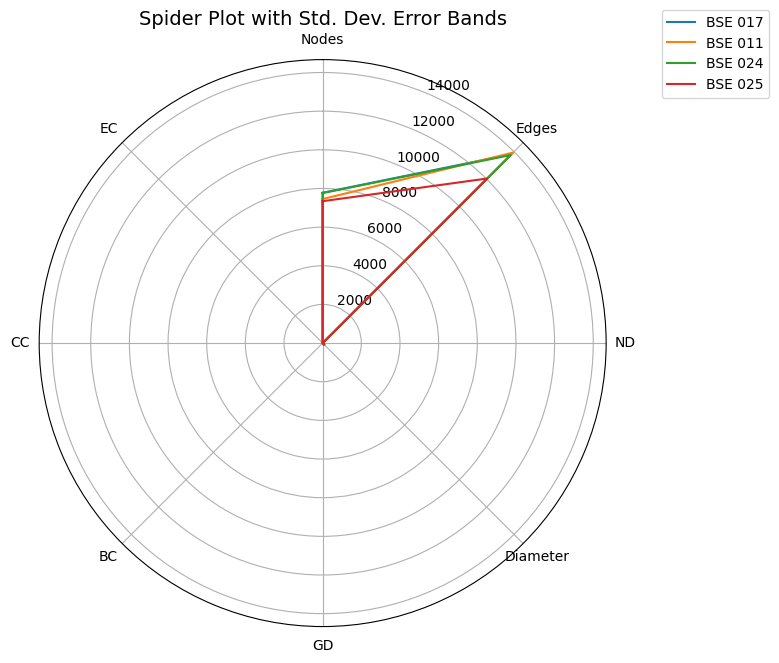

In [23]:
# Radar chart setup
labels = parameters
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
labels += [labels[0]]  # close the loop
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each material
for mat in materials:
    values = pivot_avg.loc[mat].tolist()
    values += [values[0]]  # close the loop

    errors = pivot_std.loc[mat].tolist()
    errors += [errors[0]]

    ax.plot(angles, values, label=mat)
    ax.fill_between(angles,
                    np.array(values) - np.array(errors),
                    np.array(values) + np.array(errors),
                    alpha=0.1)

# Final touches
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
ax.set_title("Spider Plot with Std. Dev. Error Bands", fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [24]:
def power_law_function(x, a, k):
    """
        A best-fit model that follows the power law distribution: y = a * x^(-k),
        where a and k are fitting parameters.

        Args:
            x (np.array): Array of x values
            a (float): intercept or scale factor/constant (shifts curve up/down). It does not affect the shape/decay rate of the curve (only how high the curve starts)
            k (float): exponent of the power law distribution. It defines how fast y decays as x increases.
    """
    return a * x ** (-k)

In [25]:
# we define x 100 values from a range of 0-1000
x_vals = np.linspace(0, 1000, 100)

In [26]:
for sheet_name, df_scl in all_sheets.items():
    df_scl.columns = df_scl.iloc[0]
    df_scl = df_scl[1:]
    df_scl = df_scl.dropna(axis=1)


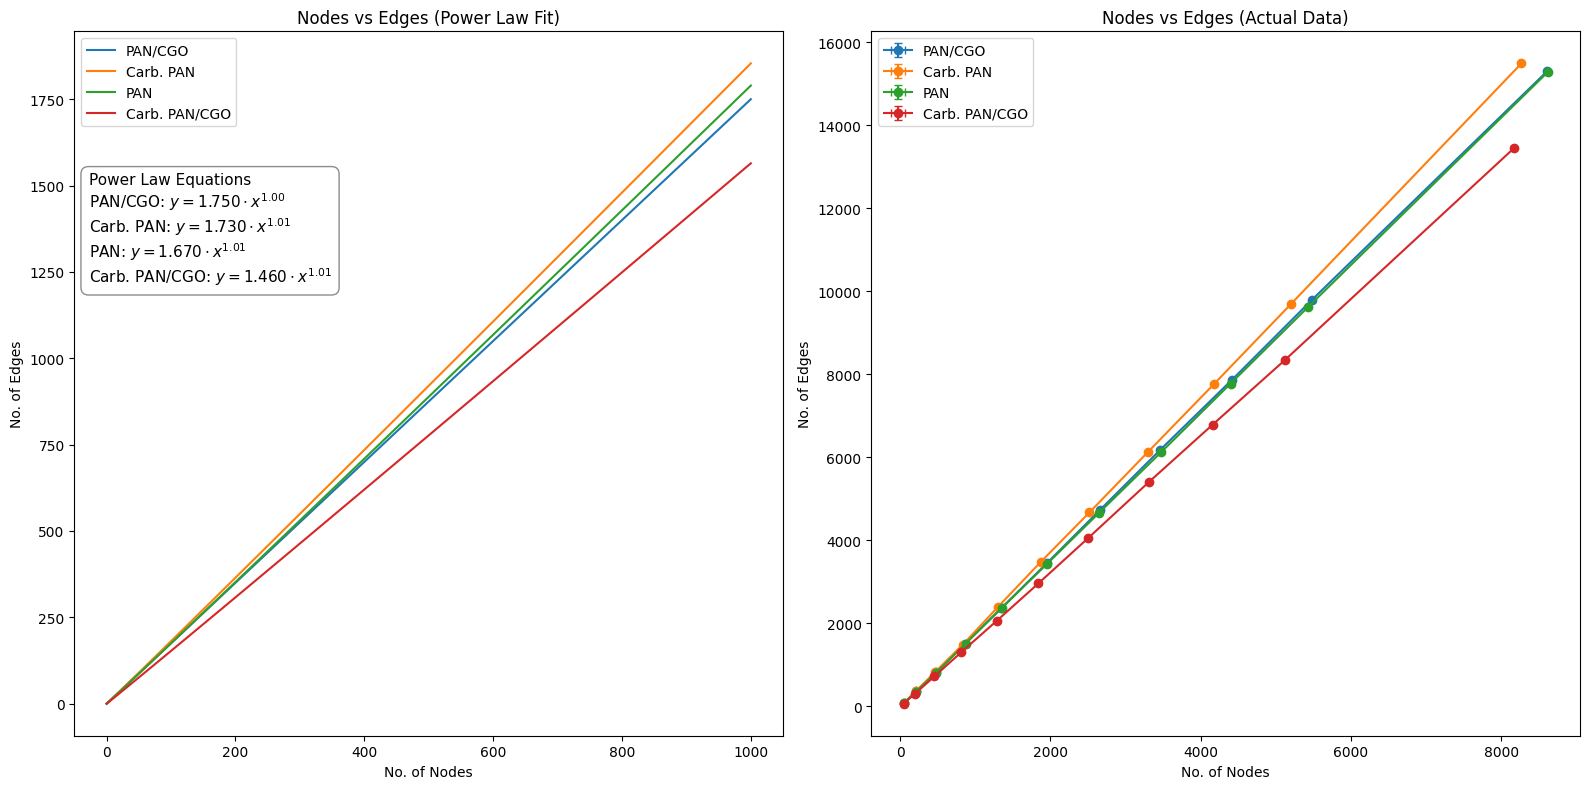

In [27]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']
data = np.loadtxt('analysis/edges.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Edges (Power Law Fit)")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("No. of Edges")
ax1.plot(x_vals, y1, label=f"PAN/CGO")
ax1.plot(x_vals, y4, label=f"Carb. PAN")
ax1.plot(x_vals, y3, label=f"PAN")
ax1.plot(x_vals, y2, label=f"Carb. PAN/CGO")
ax1.legend()
# Build equations text
eq_text = (
    r"Power Law Equations" "\n"
    r"PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a1, -k1) + "\n"
    r"Carb. PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a4, -k4) + "\n"
    r"PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a3, -k3) + "\n"
    r"Carb. PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a2, -k2)
)
# Add a text box
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax1.text(.02, 0.8, eq_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for i, sample in enumerate(materials):
    df_sample = df_edges[df_edges['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('No. of Edges')
ax2.set_title('Nodes vs Edges (Actual Data)')
ax2.legend()
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_edges.png', dpi=300)
plt.show()

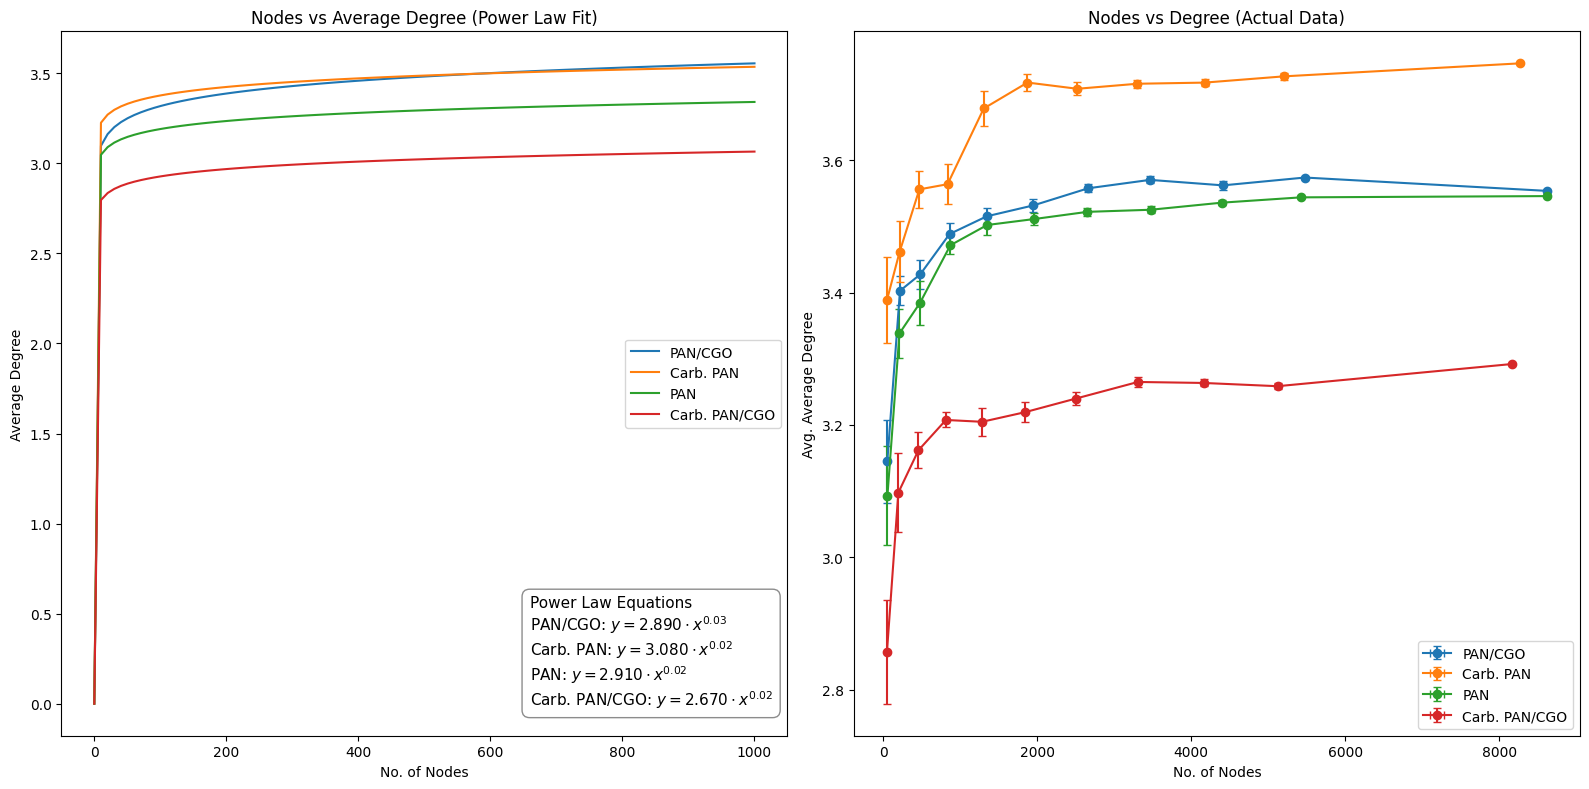

In [34]:
"""
Average Degree
"""
df_deg = all_sheets['Nodes-Degree']
data = np.loadtxt('analysis/degree.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Average Degree (Power Law Fit)")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Average Degree")
ax1.plot(x_vals, y1, label=f"PAN/CGO")
ax1.plot(x_vals, y4, label=f"Carb. PAN")
ax1.plot(x_vals, y3, label=f"PAN")
ax1.plot(x_vals, y2, label=f"Carb. PAN/CGO")
ax1.legend()
# Build equations text
eq_text = (
    r"Power Law Equations" "\n"
    r"PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a1, -k1) + "\n"
    r"Carb. PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a4, -k4) + "\n"
    r"PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a3, -k3) + "\n"
    r"Carb. PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a2, -k2)
)
# Add a text box
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax1.text(.645, 0.2, eq_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for i, sample in enumerate(materials):
    df_sample = df_deg[df_deg['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Average Degree')
ax2.set_title('Nodes vs Degree (Actual Data)')
ax2.legend()
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_deg.png', dpi=300)
plt.show()

C:\Users\owuor\AppData\Local\Temp\1\ipykernel_7892\2429440888.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-k)


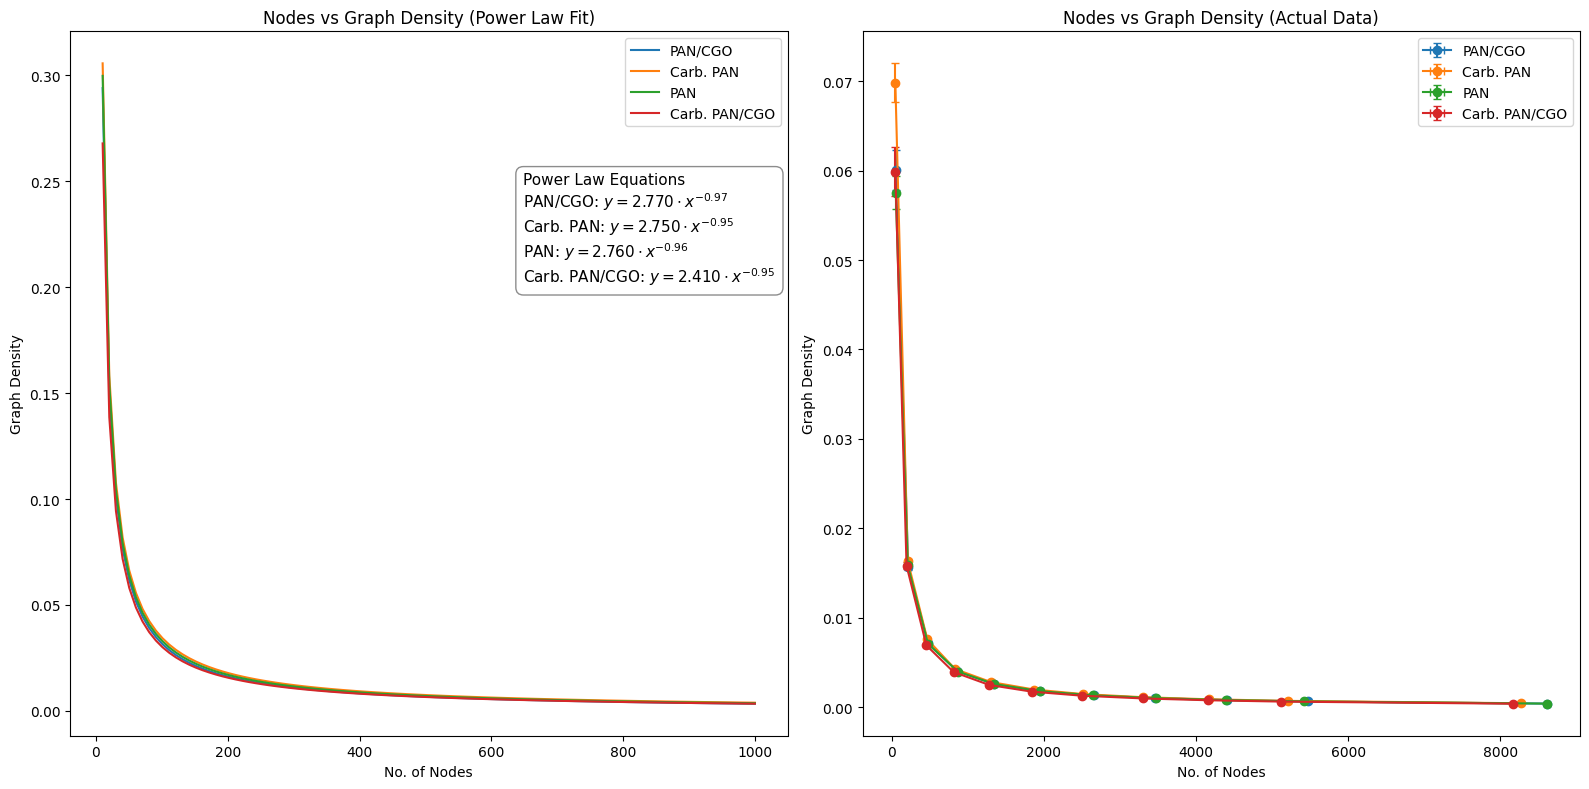

In [29]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-G. Density']
data = np.loadtxt('analysis/density.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Graph Density (Power Law Fit)")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Graph Density")
ax1.plot(x_vals, y1, label=f"PAN/CGO")
ax1.plot(x_vals, y4, label=f"Carb. PAN")
ax1.plot(x_vals, y3, label=f"PAN")
ax1.plot(x_vals, y2, label=f"Carb. PAN/CGO")
ax1.legend()
# Build equations text
eq_text = (
    r"Power Law Equations" "\n"
    r"PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a1, -k1) + "\n"
    r"Carb. PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a4, -k4) + "\n"
    r"PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a3, -k3) + "\n"
    r"Carb. PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a2, -k2)
)
# Add a text box
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax1.text(.632, 0.8, eq_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for i, sample in enumerate(materials):
    df_sample = df_dens[df_dens['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Graph Density')
ax2.set_title('Nodes vs Graph Density (Actual Data)')
ax2.legend()
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_gd.png', dpi=300)
plt.show()

C:\Users\owuor\AppData\Local\Temp\1\ipykernel_7892\2429440888.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-k)


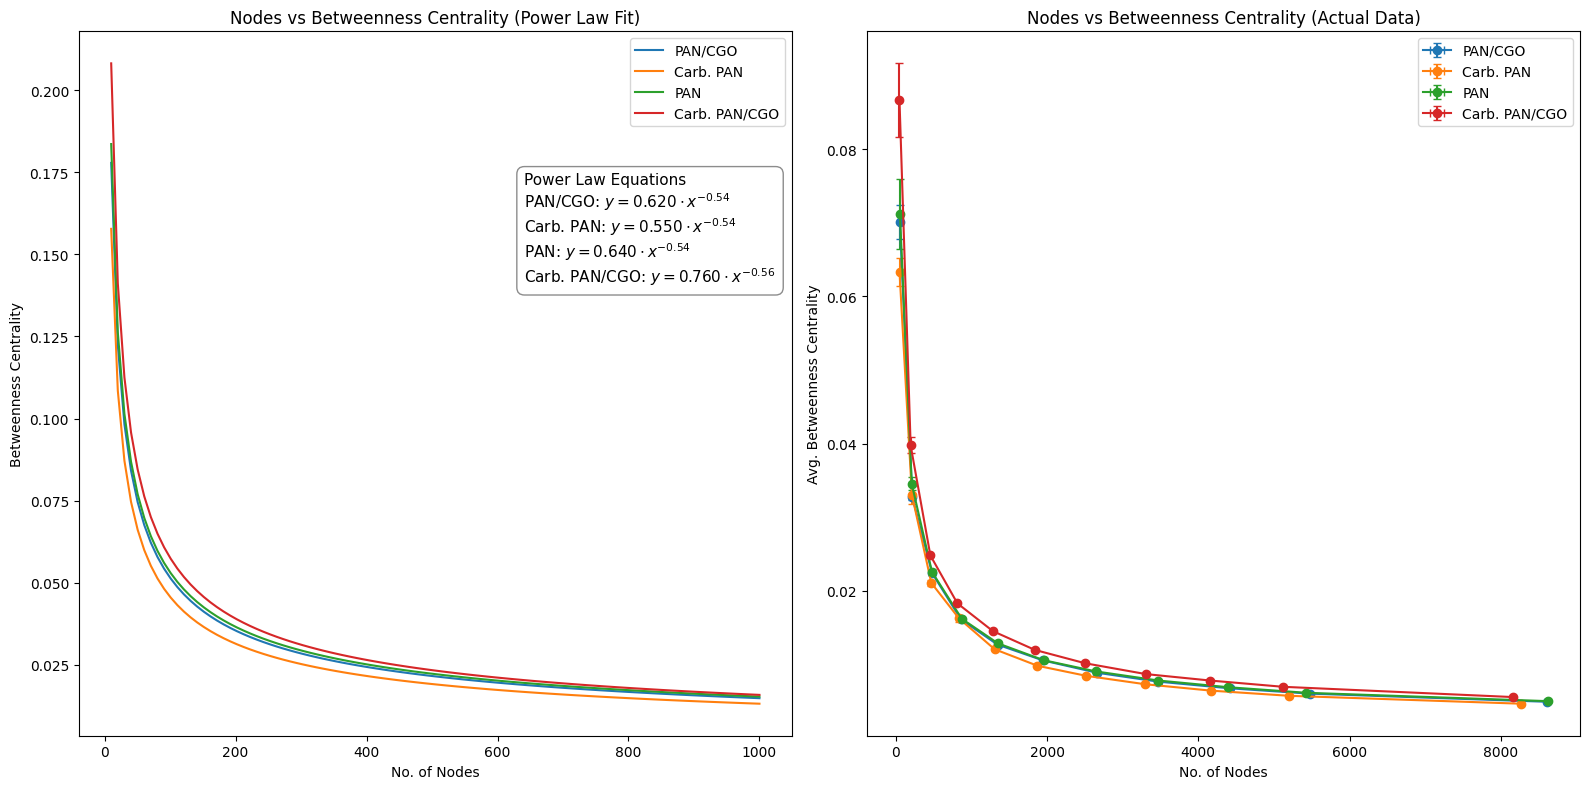

In [30]:
"""
Betweenness
"""
df_betwn = all_sheets['Nodes-Avg. Btwn. C']
data = np.loadtxt('analysis/betweenness.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Betweenness Centrality (Power Law Fit)")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Betweenness Centrality")
ax1.plot(x_vals, y1, label=f"PAN/CGO")
ax1.plot(x_vals, y4, label=f"Carb. PAN")
ax1.plot(x_vals, y3, label=f"PAN")
ax1.plot(x_vals, y2, label=f"Carb. PAN/CGO")
ax1.legend()
# Build equations text
eq_text = (
    r"Power Law Equations" "\n"
    r"PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a1, -k1) + "\n"
    r"Carb. PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a4, -k4) + "\n"
    r"PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a3, -k3) + "\n"
    r"Carb. PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a2, -k2)
)
# Add a text box
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax1.text(.625, 0.8, eq_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for i, sample in enumerate(materials):
    df_sample = df_betwn[df_betwn['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Betweenness Centrality')
ax2.set_title('Nodes vs Betweenness Centrality (Actual Data)')
ax2.legend()
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_bc.png', dpi=300)
plt.show()

C:\Users\owuor\AppData\Local\Temp\1\ipykernel_7892\2429440888.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-k)


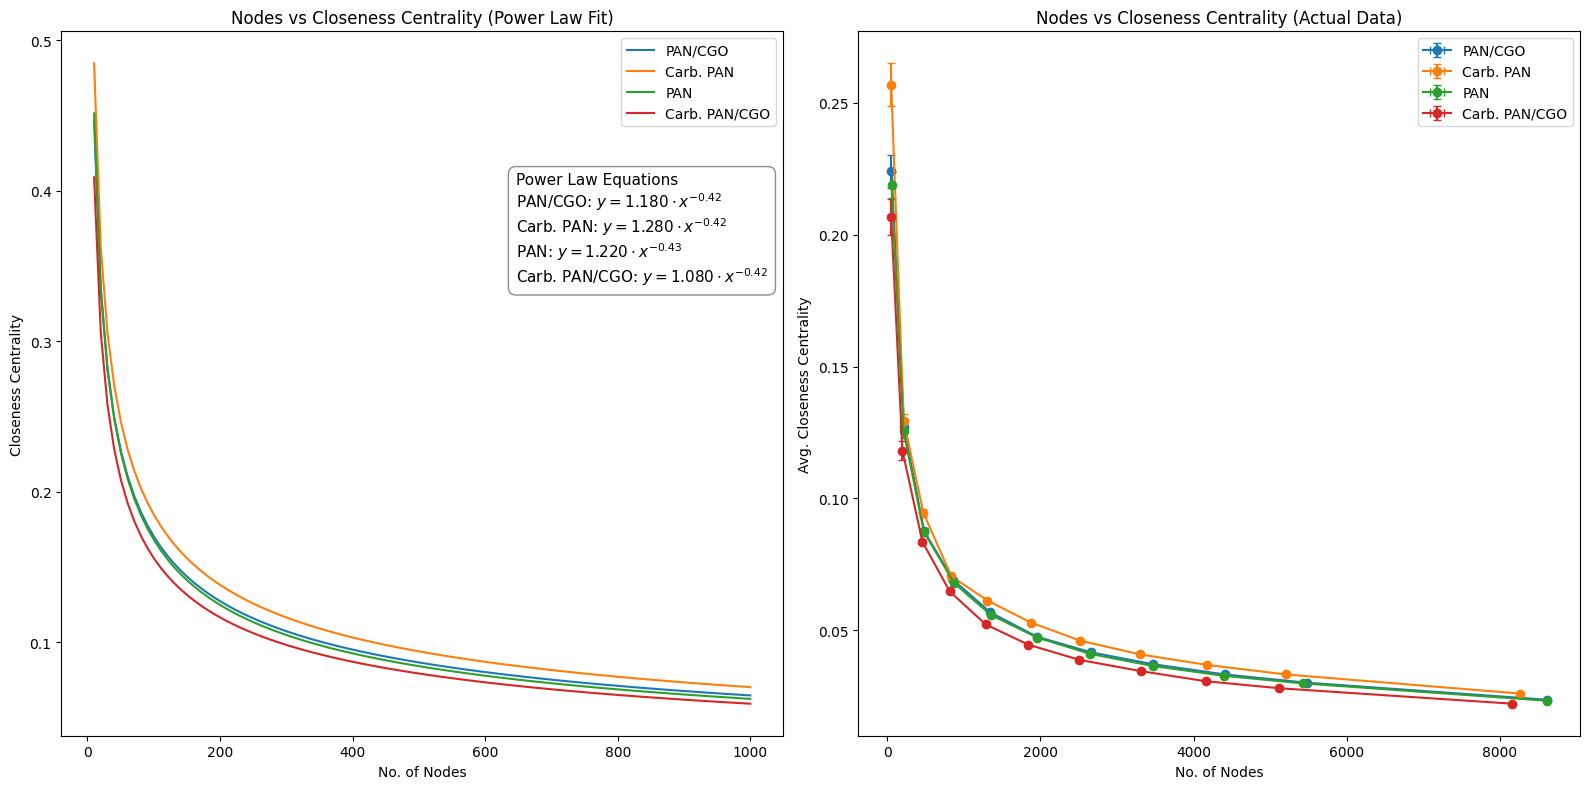

In [31]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-Avg. Close. C']
data = np.loadtxt('analysis/closeness.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Closeness Centrality (Power Law Fit)")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Closeness Centrality")
ax1.plot(x_vals, y1, label=f"PAN/CGO")
ax1.plot(x_vals, y4, label=f"Carb. PAN")
ax1.plot(x_vals, y3, label=f"PAN")
ax1.plot(x_vals, y2, label=f"Carb. PAN/CGO")
ax1.legend()
# Build equations text
eq_text = (
    r"Power Law Equations" "\n"
    r"PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a1, -k1) + "\n"
    r"Carb. PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a4, -k4) + "\n"
    r"PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a3, -k3) + "\n"
    r"Carb. PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a2, -k2)
)
# Add a text box
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax1.text(.63, 0.8, eq_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for i, sample in enumerate(materials):
    df_sample = df_clo[df_clo['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Closeness Centrality')
ax2.set_title('Nodes vs Closeness Centrality (Actual Data)')
ax2.legend()
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_cc.png', dpi=300)
plt.show()

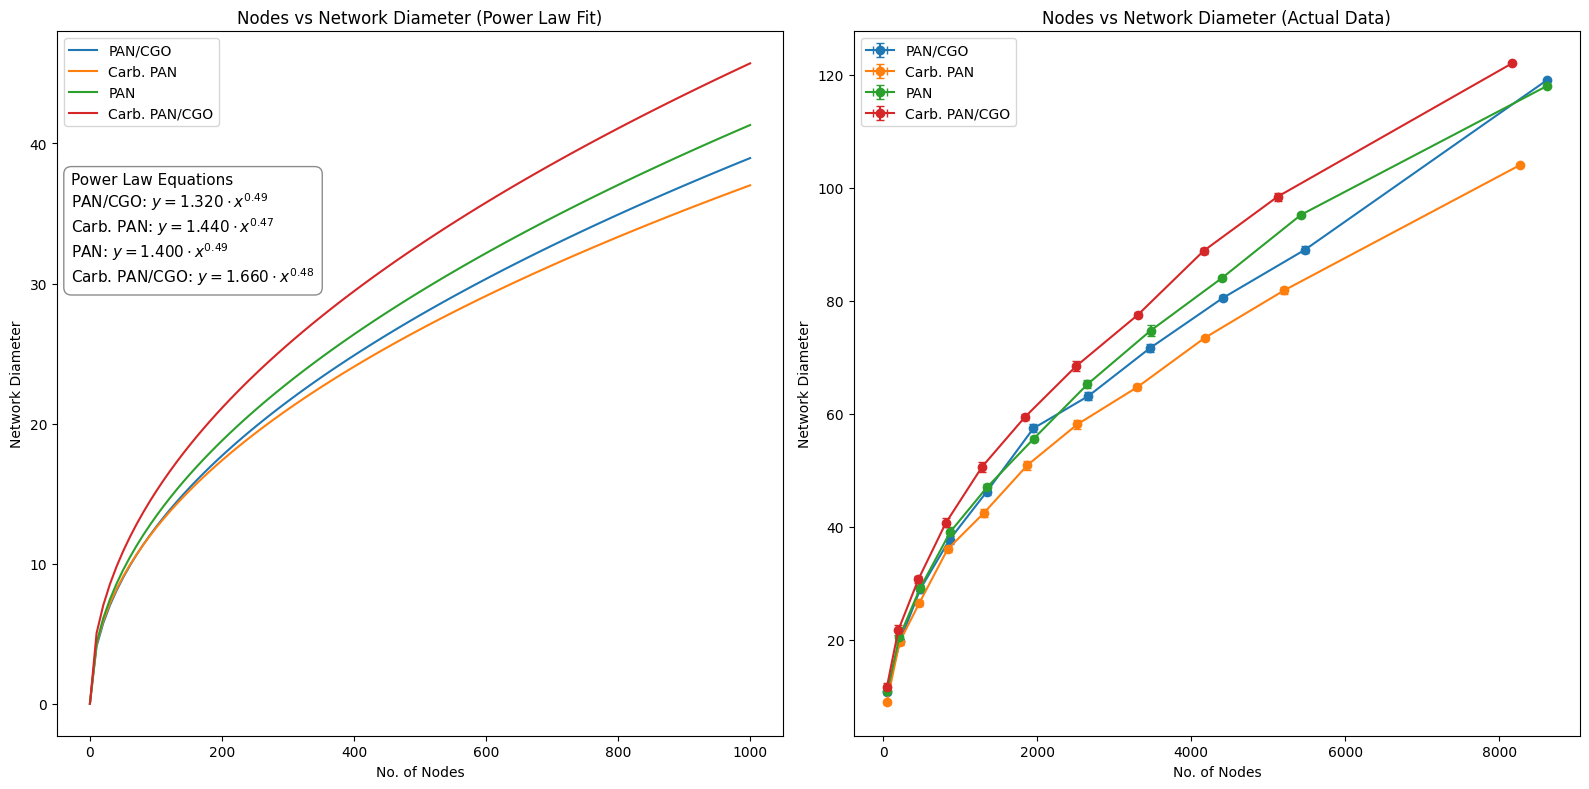

In [32]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']
data = np.loadtxt('analysis/diameter.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Network Diameter (Power Law Fit)")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Network Diameter")
ax1.plot(x_vals, y1, label=f"PAN/CGO")
ax1.plot(x_vals, y4, label=f"Carb. PAN")
ax1.plot(x_vals, y3, label=f"PAN")
ax1.plot(x_vals, y2, label=f"Carb. PAN/CGO")
ax1.legend()
# Build equations text
eq_text = (
    r"Power Law Equations" "\n"
    r"PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a1, -k1) + "\n"
    r"Carb. PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a4, -k4) + "\n"
    r"PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a3, -k3) + "\n"
    r"Carb. PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a2, -k2)
)
# Add a text box
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax1.text(.02, 0.8, eq_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for i, sample in enumerate(materials):
    df_sample = df_dia[df_dia['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Network Diameter')
ax2.set_title('Nodes vs Network Diameter (Actual Data)')
ax2.legend()
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_nd.png', dpi=300)
plt.show()

C:\Users\owuor\AppData\Local\Temp\1\ipykernel_7892\2429440888.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-k)


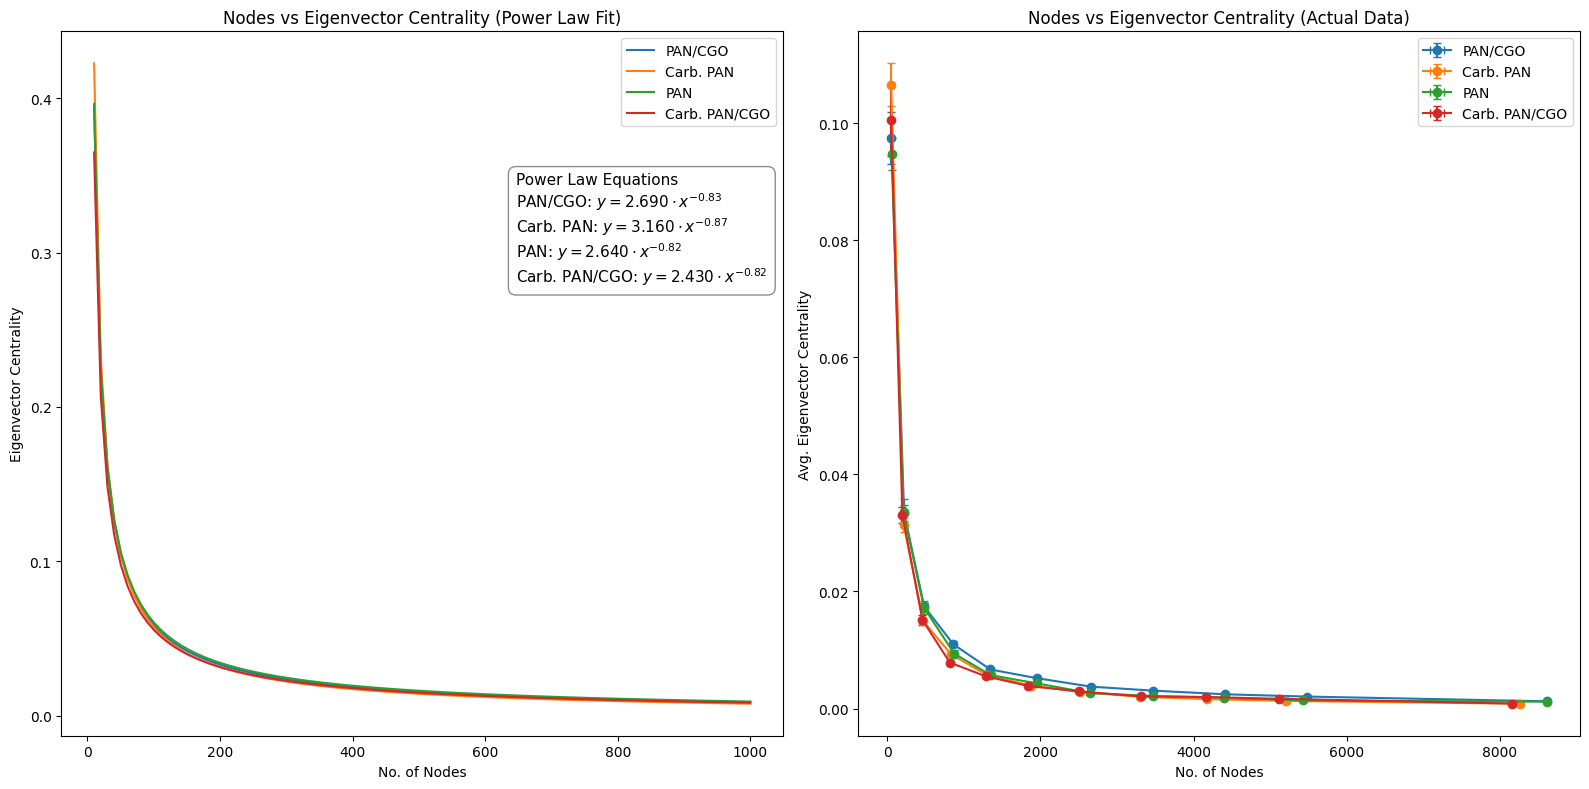

In [33]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-Avg. EigVec. C.']
data = np.loadtxt('analysis/eigenvec.csv', delimiter=',', skiprows=1)

a1, k1 = data[0,0], data[0,1]
a2, k2 = data[1,0], data[1,1]
a3, k3 = data[2,0], data[2,1]
a4, k4 = data[3,0], data[3,1]

y1 = power_law_function(x_vals, a1, k1)
y2 = power_law_function(x_vals, a2, k2)
y3 = power_law_function(x_vals, a3, k3)
y4 = power_law_function(x_vals, a4, k4)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title("Nodes vs Eigenvector Centrality (Power Law Fit)")
ax1.set_xlabel("No. of Nodes")
ax1.set_ylabel("Eigenvector Centrality")
ax1.plot(x_vals, y1, label=f"PAN/CGO")
ax1.plot(x_vals, y4, label=f"Carb. PAN")
ax1.plot(x_vals, y3, label=f"PAN")
ax1.plot(x_vals, y2, label=f"Carb. PAN/CGO")
ax1.legend()
# Build equations text
eq_text = (
    r"Power Law Equations" "\n"
    r"PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a1, -k1) + "\n"
    r"Carb. PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a4, -k4) + "\n"
    r"PAN: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a3, -k3) + "\n"
    r"Carb. PAN/CGO: $y = {:.3f} \cdot x^{{{:.2f}}}$".format(a2, -k2)
)
# Add a text box
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax1.text(.63, 0.8, eq_text, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()

ax2 = fig.add_subplot(1, 2, 2)
for i, sample in enumerate(materials):
    df_sample = df_eig[df_eig['Material'] == sample].copy()
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Eigenvector Centrality')
ax2.set_title('Nodes vs Eigenvector Centrality (Actual Data)')
ax2.legend()
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_ec.png', dpi=300)
plt.show()

     Dim.      mean       std
0    65.0  2.370067  0.014555
1   130.0  2.317501  0.009646
2   196.0  2.164711  0.012413
3   262.0  2.247962  0.010545
4   327.0  2.182972  0.023582
5   393.0  2.132420  0.007710
6   458.0  2.107074  0.011807
7   524.0  2.195704  0.012151
8   589.0  2.165887  0.019905
9   655.0  2.135714  0.015935
10  665.0  2.120068       NaN


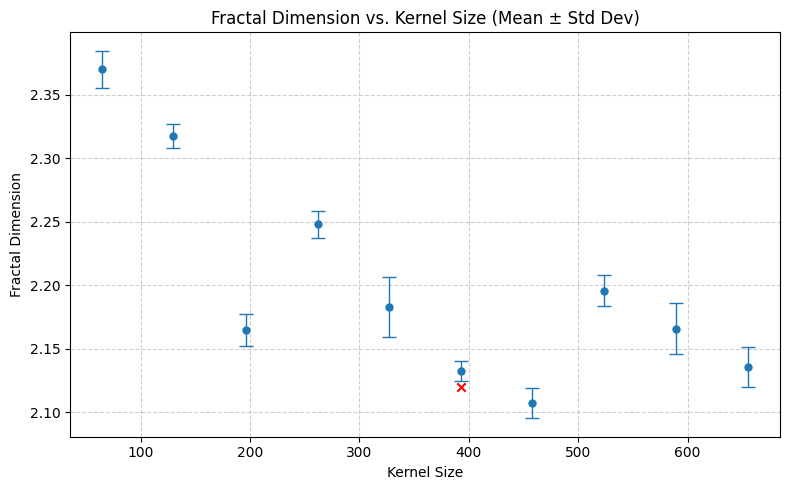

In [22]:
# Read CSV file (no header, so we set names)
df = pd.read_csv("analysis/BSE_011_FD.csv")

# Group by Dimension and calculate mean and std
stats = df.groupby("Dim.")["FD"].agg(['mean', 'std']).reset_index()
print(stats)

# Find the best dimension
stats_arr = stats.to_numpy()
orig_fd = stats_arr[-1, 1]
diff = np.inf
best_dim = None
stats_arr = stats_arr[:-1, :]
for item in stats_arr:
    curr_diff = abs(item[1] - orig_fd)
    if curr_diff < diff:
        diff = curr_diff
        best_dim = item[0]
best_dim_fd = [best_dim, orig_fd]

# remove original FD
stats = stats.drop(stats.index[-1])

# Plot with error bars
plt.figure(figsize=(8, 5))
plt.errorbar(
    stats["Dim."], stats["mean"],
    yerr=stats["std"],
    fmt='o', capsize=5, elinewidth=1, markersize=5
)
plt.scatter(best_dim_fd[0], best_dim_fd[1], marker='x', color='red')

plt.xlabel("Kernel Size")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Kernel Size (Mean ± Std Dev)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()